# Note
1. 特征选择与构造
状态 $\boldsymbol s_t=\begin{bmatrix}q_t\\v_t\end{bmatrix}$，是**二维列向量**
特征函数 $\phi(\boldsymbol s_t)$ **人为自主选定**，形式不唯一，输出一行特征向量
批量拼接构成特征矩阵：
$$
\Phi =
\begin{bmatrix}
\phi(\boldsymbol s_0)\\
\phi(\boldsymbol s_1)\\
\vdots\\
\phi(\boldsymbol s_{N-1})
\end{bmatrix}
$$

**常用特征示例**
- 线性特征：$\phi(\boldsymbol s_t)=\begin{bmatrix}q_t,\;v_t,\;1\end{bmatrix}$（单条样本3维行向量）
- 多项式特征：$\phi(\boldsymbol s_t)=\begin{bmatrix}q_t,\;v_t,\;q_t^2,\;v_t^2,\;1\end{bmatrix}$
- 物理非线性特征：$\phi(\boldsymbol s_t)=\begin{bmatrix}q_t,\;v_t,\;\sin q_t,\;1\end{bmatrix}$

2. 时序错位标签
轨迹 $\boldsymbol s_0,\boldsymbol s_1,\dots,\boldsymbol s_N$ 时序错位拆分，标签为下一时刻状态
- 单预测分量：$Y$ 为列向量
- 本例同时预测角度、角速度：$Y$ 为二维矩阵
$$
Y =
\begin{bmatrix}
\boldsymbol s_1\\
\boldsymbol s_2\\
\vdots\\
\boldsymbol s_N
\end{bmatrix}
$$

3. 线性方程组形式
对标 $Ax=b$
$$\Phi \Theta = Y$$
映射：$A=\Phi,\ x=\Theta,\ b=Y$
解出参数即可递推预测后续状态

---

## 1️⃣ 先写出单摆的牛顿运动方程

你现在的系统是一个**阻尼单摆**，对应的转动形式牛顿第二定律：
$$
I\,\ddot{q} = \tau
$$
- $q$：摆角（弧度）
- $\ddot{q}$：角加速度（二阶导数）
- $I$：转动惯量，我们这里取 $I=1$（简化模型）
- $\tau$：合外力矩

作用在摆上的力矩主要有两个：
1.  **重力恢复力矩**：使摆回到平衡位置，方向与位移相反，大小为 $-k\sin q$（$k$ 是与重力、摆长相关的常数）
2.  **阻尼力矩**：与角速度反向，用来模拟空气阻力，大小为 $-b\dot{q}$（$b$ 是阻尼系数）

所以总力矩：
$$
\tau = -k\sin q - b\dot{q}
$$

因为我们取 $I=1$，方程就变成：
$$
\ddot{q} = -k\sin q - b\dot{q}
$$

---

## 2️⃣ 把二阶 ODE 拆成一阶方程组

我们通常用状态向量来写系统，定义状态：
$$
\boldsymbol{x} =
\begin{bmatrix}
q \\
v
\end{bmatrix}
$$
其中 $v = \dot{q}$（角速度）。

对状态求导：
$$
\dot{\boldsymbol{x}} =
\begin{bmatrix}
\dot{q} \\
\dot{v}
\end{bmatrix}
=
\begin{bmatrix}
v \\
\ddot{q}
\end{bmatrix}
$$

把上面的二阶方程代入：
$$
\dot{v} = -k\sin q - bv
$$

所以系统的一阶微分方程组是：
$$
\begin{cases}
\dot{q} = v \\
\dot{v} = -k\sin q - bv
\end{cases}
$$

---

## 3️⃣ 用欧拉法做离散化（时间步长 dt）

我们要从连续时间变成代码里的离散更新形式，用**向前欧拉法**近似：
$$
\dot{q} \approx \frac{q_{t+1} - q_t}{dt}, \quad
\dot{v} \approx \frac{v_{t+1} - v_t}{dt}
$$

把这两个近似代回上面的方程组：

1.  对角度更新：
    $$
    \frac{q_{t+1} - q_t}{dt} = v_t
    $$
    移项得：
    $$
    q_{t+1} = q_t + v_t \cdot dt
    $$

2.  对角速度更新：
    $$
    \frac{v_{t+1} - v_t}{dt} = -k\sin q_t - b v_t
    $$
    移项整理：
    $$
    v_{t+1} = v_t + \left(-k\sin q_t - b v_t\right) dt
    $$

这就是你代码里的两个更新式：
```python
q_next = q + v * dt
v_next = v + (-k * np.sin(q) - damping * v) * dt
```
（代码里的 `damping` 就是这里的 $b$）

---

## 4️⃣ 总结一下每一项的物理意义

| 项 | 物理含义 |
| :--- | :--- |
| $v_t$ | 当前角速度 |
| $-k\sin q_t$ | 重力带来的恢复力矩（导致摆往回摆） |
| $-b v_t$ | 阻尼带来的阻力（让摆动慢慢停下来） |
| $\cdot dt$ | 把“加速度”（单位时间速度变化）变成“一个时间步的速度变化量” |

---

## 5️⃣ 补充：为什么用线性模型拟合会有误差？

这个真实动力学里，$\sin q$ 是一个**非线性项**。
你一开始用的线性模型：
$$
\Delta v \approx \theta_1 q + \theta_2 v + \theta_3
$$
根本无法精确拟合 $\sin q$ 这种非线性关系，所以会出现你看到的系统性偏差（Sine pattern）。

---

如果你愿意，我可以帮你把这个推导改成一个**线性化版本**，看看当 $q$ 很小时，这个系统会变成什么样，以及为什么线性模型在小角度下效果会变好。

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [8]:
dt = 0.05
k = 1.0
damping = 0.05


def true_next_state(states, dt=dt, k=k, damping=damping):
    """
    Vectorised true dynamics.

    states shape: (N, 2)
    state columns: [q, v]

    returns next_states shape: (N, 2)
    """
    states = np.asarray(states)

    q = states[:, 0]
    v = states[:, 1]

    q_next = q + v * dt
    v_next = v + (-k * np.sin(q) - damping * v) * dt

    next_states = np.column_stack([q_next, v_next])

    return next_states

In [10]:
test_states = np.array([
    [0.0, 1.0],
    [1.0, 0.0],
    [2.0, -1.0],
])

test_next_states = true_next_state(test_states)

print("test_states shape:", test_states.shape)
print("test_next_states shape:", test_next_states.shape)

print("test_states:")
print(test_states)

print("\ntest_next_states:")
print(test_next_states)

test_states shape: (3, 2)
test_next_states shape: (3, 2)
test_states:
[[ 0.  1.]
 [ 1.  0.]
 [ 2. -1.]]

test_next_states:
[[ 0.05        0.9975    ]
 [ 1.         -0.04207355]
 [ 1.95       -1.04296487]]


In [12]:
N = 1000

q_samples = np.random.uniform(-3.0, 3.0, size=N)
v_samples = np.random.uniform(-2.0, 2.0, size=N)

X = np.column_stack([q_samples, v_samples])
X_next = true_next_state(X)

Delta_X = X_next - X

print("q_samples shape:", q_samples.shape)
print("v_samples shape:", v_samples.shape)
print("X shape:", X.shape)
print("X_next shape:", X_next.shape)
print("Delta_X shape:", Delta_X.shape)

print("\nFirst 5 states X:")
print(X[:5])

print("\nFirst 5 Delta_X:")
print(Delta_X[:5])

q_samples shape: (1000,)
v_samples shape: (1000,)
X shape: (1000, 2)
X_next shape: (1000, 2)
Delta_X shape: (1000, 2)

First 5 states X:
[[ 0.29288102  0.37152108]
 [ 1.2911362  -1.95974522]
 [ 0.61658026 -0.09669522]
 [ 0.2692991   0.83508156]
 [-0.4580712  -1.82409827]]

First 5 Delta_X:
[[ 0.01857605 -0.01536439]
 [-0.09798726 -0.0431581 ]
 [-0.00483476 -0.02867069]
 [ 0.04175408 -0.0153905 ]
 [-0.09120491  0.02667119]]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_sampled_state_space.png


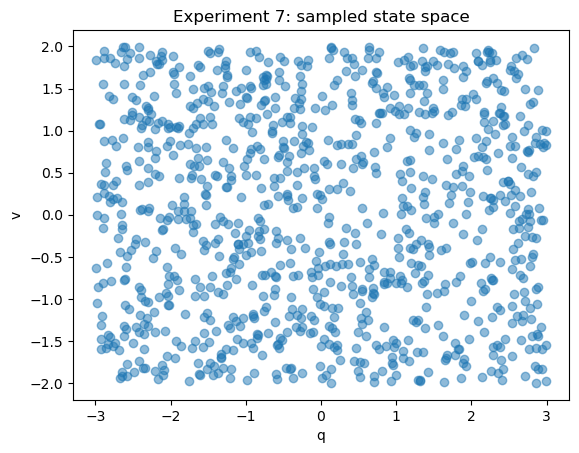

In [14]:
fig, ax = plt.subplots()

ax.scatter(X[:, 0], X[:, 1], alpha=0.5)

ax.set_xlabel("q")
ax.set_ylabel("v")
ax.set_title("Experiment 7: sampled state space")

fig_path = FIGURE_DIR / "exp7_sampled_state_space.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [16]:
# def make_linear_features(states):
#     """
#     Construct linear feature matrix [q, v, 1].

#     states shape: (N, 2) or (2,)
#     returned Phi shape: (N, 3)
#     """
#     states = np.asarray(states)

#     if states.ndim == 1:
#         states = states[None, :]

#     n_samples = states.shape[0]
#     ones = np.ones(n_samples)

#     Phi = np.column_stack([states[:, 0], states[:, 1], ones])

#     return Phi

def make_nonlinear_features(states):
    """
    构造非线性特征矩阵 [q, v, sin(q), 1]
    专门解决 delta v 里的 sine pattern 误差！

    states shape: (N, 2) or (2,)
    returned Phi shape: (N, 4)
    """
    states = np.asarray(states)

    if states.ndim == 1:
        states = states[None, :]

    q = states[:, 0]  # 角度
    v = states[:, 1]  # 角速度
    sin_q = np.sin(q)  # ✅ 关键：加入真实物理非线性项
    ones = np.ones(len(q))

    # 特征 = [q, v, sin(q), 1]
    Phi = np.column_stack([q, v, sin_q, ones])

    return Phi

In [18]:
Phi_demo = make_nonlinear_features(X[:5])

print("X[:5] shape:", X[:5].shape)
print("Phi_demo shape:", Phi_demo.shape)
print(Phi_demo)

X[:5] shape: (5, 2)
Phi_demo shape: (5, 4)
[[ 0.29288102  0.37152108  0.28871176  1.        ]
 [ 1.2911362  -1.95974522  0.96114931  1.        ]
 [ 0.61658026 -0.09669522  0.57824851  1.        ]
 [ 0.2692991   0.83508156  0.26605586  1.        ]
 [-0.4580712  -1.82409827 -0.44221898  1.        ]]


In [20]:
indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = X[train_idx]
Delta_train = Delta_X[train_idx]

X_val = X[val_idx]
Delta_val = Delta_X[val_idx]

X_test = X[test_idx]
Delta_test = Delta_X[test_idx]

Phi_train = make_nonlinear_features(X_train)
Phi_val = make_nonlinear_features(X_val)
Phi_test = make_nonlinear_features(X_test)

print("X_train shape:", X_train.shape)
print("Delta_train shape:", Delta_train.shape)
print("Phi_train shape:", Phi_train.shape)

print("\nX_val shape:", X_val.shape)
print("Delta_val shape:", Delta_val.shape)
print("Phi_val shape:", Phi_val.shape)

print("\nX_test shape:", X_test.shape)
print("Delta_test shape:", Delta_test.shape)
print("Phi_test shape:", Phi_test.shape)

X_train shape: (600, 2)
Delta_train shape: (600, 2)
Phi_train shape: (600, 4)

X_val shape: (200, 2)
Delta_val shape: (200, 2)
Phi_val shape: (200, 4)

X_test shape: (200, 2)
Delta_test shape: (200, 2)
Phi_test shape: (200, 4)


In [22]:
Theta_hat, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_train,
    Delta_train,
    rcond=None
)

print("Theta_hat shape:", Theta_hat.shape)
print("Theta_hat:")
print(Theta_hat)

print("\nLeast-squares diagnostics:")
print("residuals:", residuals)
print("rank:", rank)
print("singular values:", singular_values)

Theta_hat shape: (4, 2)
Theta_hat:
[[-9.72195002e-19 -8.23583316e-18]
 [ 5.00000000e-02 -2.50000000e-03]
 [-1.39214125e-17 -5.00000000e-02]
 [-8.34846768e-18  1.60628346e-18]]

Least-squares diagnostics:
residuals: [5.8992417e-30 1.6020009e-30]
rank: 4
singular values: [44.37771018 29.17008247 24.43011122  9.47849953]


In [24]:
def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)


def mse_per_dimension(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2, axis=0)

In [26]:
Delta_pred_train = Phi_train @ Theta_hat
Delta_pred_val = Phi_val @ Theta_hat
Delta_pred_test = Phi_test @ Theta_hat

train_mse = mse(Delta_train, Delta_pred_train)
val_mse = mse(Delta_val, Delta_pred_val)
test_mse = mse(Delta_test, Delta_pred_test)

train_mse_per_dim = mse_per_dimension(Delta_train, Delta_pred_train)
val_mse_per_dim = mse_per_dimension(Delta_val, Delta_pred_val)
test_mse_per_dim = mse_per_dimension(Delta_test, Delta_pred_test)

print("Prediction shapes:")
print("Delta_pred_train shape:", Delta_pred_train.shape)
print("Delta_pred_val shape:", Delta_pred_val.shape)
print("Delta_pred_test shape:", Delta_pred_test.shape)

print("\nOne-step MSE:")
print("Train MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

print("\nOne-step MSE per dimension [Delta q, Delta v]:")
print("Train:", train_mse_per_dim)
print("Validation:", val_mse_per_dim)
print("Test:", test_mse_per_dim)

Prediction shapes:
Delta_pred_train shape: (600, 2)
Delta_pred_val shape: (200, 2)
Delta_pred_test shape: (200, 2)

One-step MSE:
Train MSE: 8.817452731466995e-33
Validation MSE: 9.175733074536119e-33
Test MSE: 8.988851582811143e-33

One-step MSE per dimension [Delta q, Delta v]:
Train: [1.46036686e-32 3.03123689e-33]
Validation: [1.54184713e-32 2.93299481e-33]
Test: [1.51346993e-32 2.84300385e-33]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_one_step_delta_q_prediction_nonlinear.png


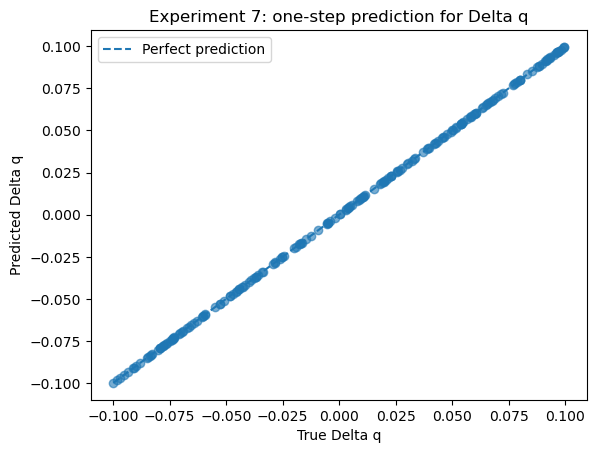

In [50]:
fig, ax = plt.subplots()

ax.scatter(Delta_test[:, 0], Delta_pred_test[:, 0], alpha=0.6)

min_value = min(Delta_test[:, 0].min(), Delta_pred_test[:, 0].min())
max_value = max(Delta_test[:, 0].max(), Delta_pred_test[:, 0].max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True Delta q")
ax.set_ylabel("Predicted Delta q")
ax.set_title("Experiment 7: one-step prediction for Delta q")
ax.legend()

fig_path = FIGURE_DIR / "exp7_one_step_delta_q_prediction_nonlinear.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_one_step_delta_v_prediction_nonlinear.png


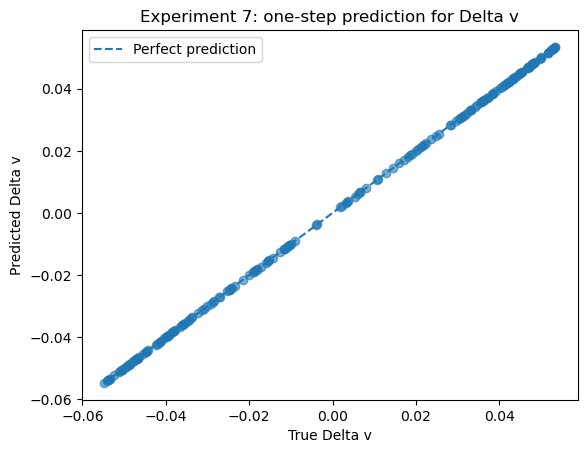

In [52]:
fig, ax = plt.subplots()

ax.scatter(Delta_test[:, 1], Delta_pred_test[:, 1], alpha=0.6)

min_value = min(Delta_test[:, 1].min(), Delta_pred_test[:, 1].min())
max_value = max(Delta_test[:, 1].max(), Delta_pred_test[:, 1].max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True Delta v")
ax.set_ylabel("Predicted Delta v")
ax.set_title("Experiment 7: one-step prediction for Delta v")
ax.legend()

fig_path = FIGURE_DIR / "exp7_one_step_delta_v_prediction_nonlinear.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [54]:
def true_step_single(state):
    """
    One true dynamics step for a single state.

    state shape: (2,)
    return shape: (2,)
    """
    next_state = true_next_state(state[None, :])[0]
    return next_state


def model_delta_single(state, Theta_hat):
    """
    Predict Delta X for one state using the learned linear model.

    state shape: (2,)
    return delta shape: (2,)
    """
    Phi = make_nonlinear_features(state)
    delta = Phi @ Theta_hat
    return delta[0]


def model_step_single(state, Theta_hat):
    """
    One learned-model step:
        X_next = X + predicted Delta X
    """
    delta = model_delta_single(state, Theta_hat)
    next_state = state + delta
    return next_state


def rollout(initial_state, num_steps, step_function):
    """
    Roll out a dynamical system.

    initial_state shape: (2,)
    returned trajectory shape: (num_steps + 1, 2)
    """
    trajectory = np.zeros((num_steps + 1, 2))
    trajectory[0] = initial_state

    for t in range(num_steps):
        trajectory[t + 1] = step_function(trajectory[t])

    return trajectory

In [36]:
initial_state_demo = np.array([2.0, 0.0])

true_next_demo = true_step_single(initial_state_demo)
model_next_demo = model_step_single(initial_state_demo, Theta_hat)

print("initial_state_demo shape:", initial_state_demo.shape)
print("true_next_demo shape:", true_next_demo.shape)
print("model_next_demo shape:", model_next_demo.shape)

print("initial_state_demo:", initial_state_demo)
print("true_next_demo:", true_next_demo)
print("model_next_demo:", model_next_demo)

initial_state_demo shape: (2,)
true_next_demo shape: (2,)
model_next_demo shape: (2,)
initial_state_demo: [2. 0.]
true_next_demo: [ 2.         -0.04546487]
model_next_demo: [ 2.         -0.04546487]


In [38]:
initial_state = np.array([2.7, 0.0])
num_steps = 400

true_trajectory = rollout(
    initial_state=initial_state,
    num_steps=num_steps,
    step_function=true_step_single
)

model_trajectory = rollout(
    initial_state=initial_state,
    num_steps=num_steps,
    step_function=lambda state: model_step_single(state, Theta_hat)
)

print("true_trajectory shape:", true_trajectory.shape)
print("model_trajectory shape:", model_trajectory.shape)

print("\nInitial state:")
print(initial_state)

print("\nFirst 5 true states:")
print(true_trajectory[:5])

print("\nFirst 5 model states:")
print(model_trajectory[:5])

true_trajectory shape: (401, 2)
model_trajectory shape: (401, 2)

Initial state:
[2.7 0. ]

First 5 true states:
[[ 2.7         0.        ]
 [ 2.7        -0.02136899]
 [ 2.69893155 -0.04268457]
 [ 2.69679732 -0.06399513]
 [ 2.69359757 -0.0853488 ]]

First 5 model states:
[[ 2.7         0.        ]
 [ 2.7        -0.02136899]
 [ 2.69893155 -0.04268457]
 [ 2.69679732 -0.06399513]
 [ 2.69359757 -0.0853488 ]]


In [40]:
rollout_errors = model_trajectory - true_trajectory

rollout_mse = np.mean(rollout_errors ** 2)
rollout_mse_per_dim = np.mean(rollout_errors ** 2, axis=0)

state_error_norm = np.linalg.norm(rollout_errors, axis=1)

print("Rollout MSE:", rollout_mse)
print("Rollout MSE per dimension [q, v]:", rollout_mse_per_dim)
print("state_error_norm shape:", state_error_norm.shape)

print("\nFinal true state:")
print(true_trajectory[-1])

print("\nFinal model state:")
print(model_trajectory[-1])

Rollout MSE: 6.500961081717194e-29
Rollout MSE per dimension [q, v]: [8.22351458e-29 4.77840758e-29]
state_error_norm shape: (401,)

Final true state:
[ 0.91971502 -1.37677542]

Final model state:
[ 0.91971502 -1.37677542]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_rollout_q_vs_time_nonlinear.png


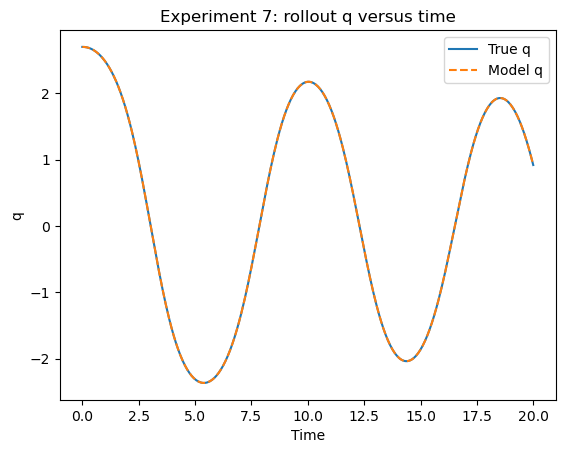

In [56]:
time = np.arange(num_steps + 1) * dt

fig, ax = plt.subplots()

ax.plot(time, true_trajectory[:, 0], label="True q")
ax.plot(time, model_trajectory[:, 0], linestyle="--", label="Model q")

ax.set_xlabel("Time")
ax.set_ylabel("q")
ax.set_title("Experiment 7: rollout q versus time")
ax.legend()

fig_path = FIGURE_DIR / "exp7_rollout_q_vs_time_nonlinear.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_rollout_v_vs_time_nonlinear.png


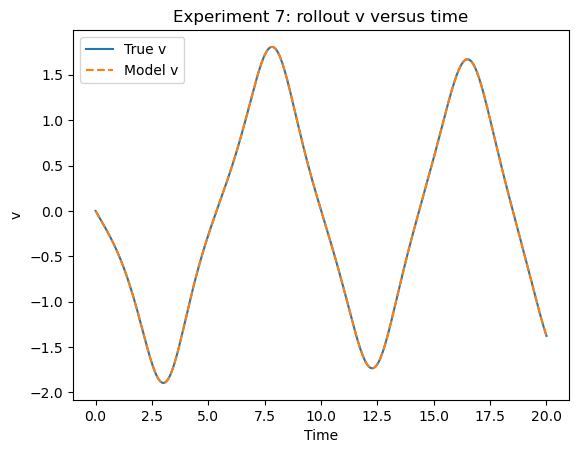

In [58]:
fig, ax = plt.subplots()

ax.plot(time, true_trajectory[:, 1], label="True v")
ax.plot(time, model_trajectory[:, 1], linestyle="--", label="Model v")

ax.set_xlabel("Time")
ax.set_ylabel("v")
ax.set_title("Experiment 7: rollout v versus time")
ax.legend()

fig_path = FIGURE_DIR / "exp7_rollout_v_vs_time_nonlinear.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_phase_portrait_nonlinear.png


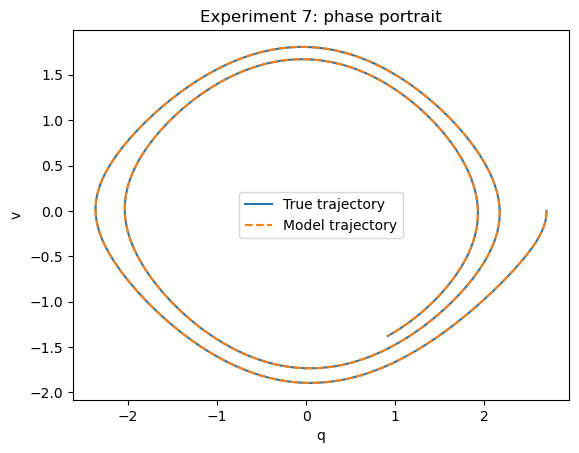

In [60]:
fig, ax = plt.subplots()

ax.plot(true_trajectory[:, 0], true_trajectory[:, 1], label="True trajectory")
ax.plot(model_trajectory[:, 0], model_trajectory[:, 1], linestyle="--", label="Model trajectory")

ax.set_xlabel("q")
ax.set_ylabel("v")
ax.set_title("Experiment 7: phase portrait")
ax.legend()

fig_path = FIGURE_DIR / "exp7_phase_portrait_nonlinear.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp7_rollout_error_vs_time_nonlinear.png


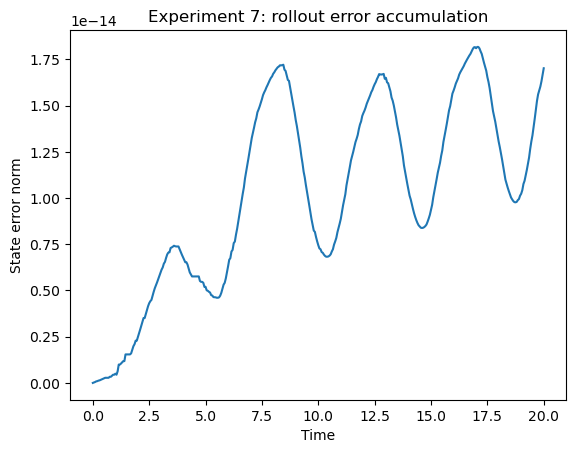

In [62]:
fig, ax = plt.subplots()

ax.plot(time, state_error_norm)

ax.set_xlabel("Time")
ax.set_ylabel("State error norm")
ax.set_title("Experiment 7: rollout error accumulation")

fig_path = FIGURE_DIR / "exp7_rollout_error_vs_time_nonlinear.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()